# Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones

## M16: Inventarios Forestales Nacionales, cálculo de biomasa y evaluación del estado de los bosques nativos

### TP3 - Aprendizaje no supervisado y profundización supervisada

**Grupo 1**

- Ahumada, Magalí
- Martín, Nicolás Eugenio
- Nedel, Agustina Itatí

## 3.1. Problema de trabajo

Luego de explorar y curar la base del Segundo Inventario Nacional de Bosques Nativos, nos interesa saber si las unidades de muestreo pueden organizarse en **tipologías de bosque que surjan de sus propias características**, sin imponer previamente la región forestal como criterio de clasificación.

La pregunta principal es:

> **¿Es posible identificar grupos de unidades de muestreo con estructuras y composiciones forestales similares a escala nacional?**

Para responderla usamos aprendizaje no supervisado. Los grupos se forman a partir de variables de estructura y diversidad y, recién después, se interpretan según su distribución regional y espacial, la regeneración, la presión antrópica y otras condiciones del sitio.

Como análisis complementario, evaluamos en qué medida algunas características de la parcela permiten estimar su biomasa. Esta segunda parte no busca reemplazar el análisis de tipologías, sino profundizar uno de sus principales ejes estructurales.

### Decisiones tomadas a partir del TP2 y de la devolución

- Se trabaja a nivel de **unidad de muestreo (UM)**, incorporando las variables de composición y estructura agregadas desde la tabla de individuos.
- Las 76 UM sin individuos inventariables se conservan en la base curada, pero no se usan para construir tipologías forestales. En ellas, la ausencia de individuos puede describir el sitio relevado, aunque no corresponde incluirlas en estimaciones sobre estructura de bosque.
- Los individuos arbustivos no tienen área basal igual a cero: en muchos casos no puede calcularse porque solo se midieron diámetros de copa y no se dispone de DAP o DAB. Esta limitación se mantiene diferenciada de una ausencia real.
- Los valores extremos biológicamente plausibles no se eliminan. Para evitar que dominen las distancias, se acotan temporalmente al percentil 1-99 solo dentro de la matriz usada para clustering; los perfiles finales se describen con los valores originales.
- Como se trata de un análisis no supervisado sobre el conjunto nacional seleccionado, `RobustScaler` se ajusta sobre ese conjunto completo. El dataset curado original permanece sin escalar.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, r2_score, mean_absolute_error, mean_squared_error
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GroupKFold
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

SEED = 42
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

## 3.2. Carga y definición del universo de análisis

El TP3 parte de `INBN2_um_curado.csv`, generado al final del TP2. El archivo conserva las variables originales útiles, las correcciones documentadas y los indicadores construidos a nivel de parcela.

In [2]:
from pathlib import Path

rutas_posibles = [
    Path('INBN2_um_curado.csv'),
    Path('/content/INBN2_um_curado.csv'),
]
ruta_datos = next((p for p in rutas_posibles if p.exists()), None)

if ruta_datos is None:
    raise FileNotFoundError(
        'No se encontró INBN2_um_curado.csv. Subir el archivo generado por el TP2 '
        'al mismo directorio del notebook y volver a ejecutar.'
    )

df = pd.read_csv(ruta_datos, low_memory=False)
print('Dataset curado:', df.shape)
print('UM sin individuos inventariables:', int(df['SIN_IND_INVENTARIABLE'].sum()))

df_modelo = df.loc[df['SIN_IND_INVENTARIABLE'].eq(0)].copy()
print('UM consideradas para construir las tipologías:', len(df_modelo))

Dataset curado: (3891, 106)
UM sin individuos inventariables: 76
UM consideradas para construir las tipologías: 3815


## 3.3. Una primera mirada espacial a la diversidad

La devolución del TP2 sugirió explorar los patrones espaciales de las variables de composición. Antes de formar los grupos, ubicamos la riqueza y la diversidad de Shannon en el territorio. El objetivo no es afirmar que existe una relación causal con la localización, sino observar si aparecen concentraciones o transiciones que luego ayuden a interpretar las tipologías.

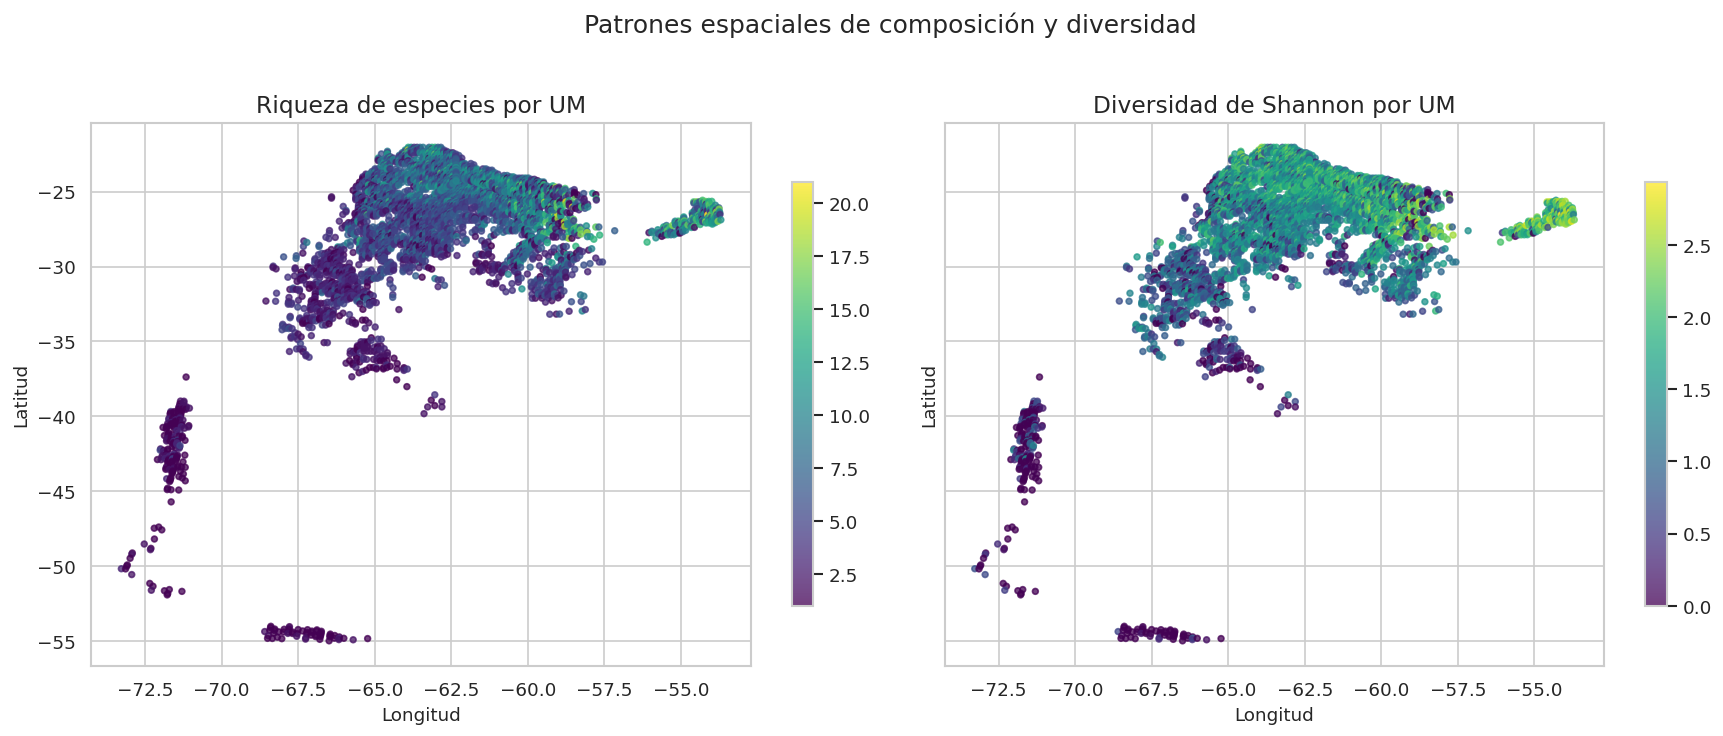

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

for ax, variable, titulo in [
    (axes[0], 'RIQUEZA_ESPECIES', 'Riqueza de especies por UM'),
    (axes[1], 'SHANNON', 'Diversidad de Shannon por UM'),
]:
    sc = ax.scatter(
        df_modelo['LONGITUD'], df_modelo['LATITUD'],
        c=df_modelo[variable], cmap='viridis', s=12, alpha=0.75
    )
    ax.set_title(titulo)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    plt.colorbar(sc, ax=ax, shrink=0.78)

plt.suptitle('Patrones espaciales de composición y diversidad', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

Los mapas muestran que la diversidad no se distribuye de manera uniforme. Las parcelas del centro-norte concentran los valores más altos, aunque también existe heterogeneidad dentro de una misma zona. Esto anticipa que la región puede ayudar a interpretar los grupos, pero no necesariamente los determina por completo.

## 3.4. Selección de variables para formar los grupos

Elegimos seis variables que representan dimensiones distintas del bosque:

| Dimensión | Variable | Qué representa |
|---|---|---|
| Existencias | `BIOMASA_TN_HA` | Biomasa acumulada por hectárea |
| Densidad | `CANTIDAD_IND_VIVOS_HA` | Cantidad de individuos vivos por hectárea |
| Porte | `DAP_MEDIO` | Tamaño medio de los individuos |
| Heterogeneidad | `DAP_CV` | Variabilidad de los diámetros dentro de la parcela |
| Composición | `RIQUEZA_ESPECIES` | Número de especies registradas |
| Diversidad | `SHANNON` | Diversidad considerando riqueza y abundancia relativa |

No incluimos simultáneamente biomasa, volumen y área basal porque están fuertemente relacionados y repetirían una misma dimensión dentro de la distancia. Tampoco usamos región, coordenadas, presión antrópica ni variables ambientales para formar los grupos: se reservan para interpretarlos.

In [4]:
variables_cluster = [
    'BIOMASA_TN_HA',
    'CANTIDAD_IND_VIVOS_HA',
    'DAP_MEDIO',
    'DAP_CV',
    'RIQUEZA_ESPECIES',
    'SHANNON',
]

faltantes_cluster = df_modelo[variables_cluster].isna().sum().rename('nulos')
display(faltantes_cluster.to_frame())

df_cluster = df_modelo.dropna(subset=variables_cluster).copy()
print(f'UM completas para clustering: {len(df_cluster)} de {len(df_modelo)}')

UM completas para clustering: 3790 de 3815


,nulos
BIOMASA_TN_HA,0
CANTIDAD_IND_VIVOS_HA,0
DAP_MEDIO,0
DAP_CV,25
RIQUEZA_ESPECIES,0
SHANNON,0


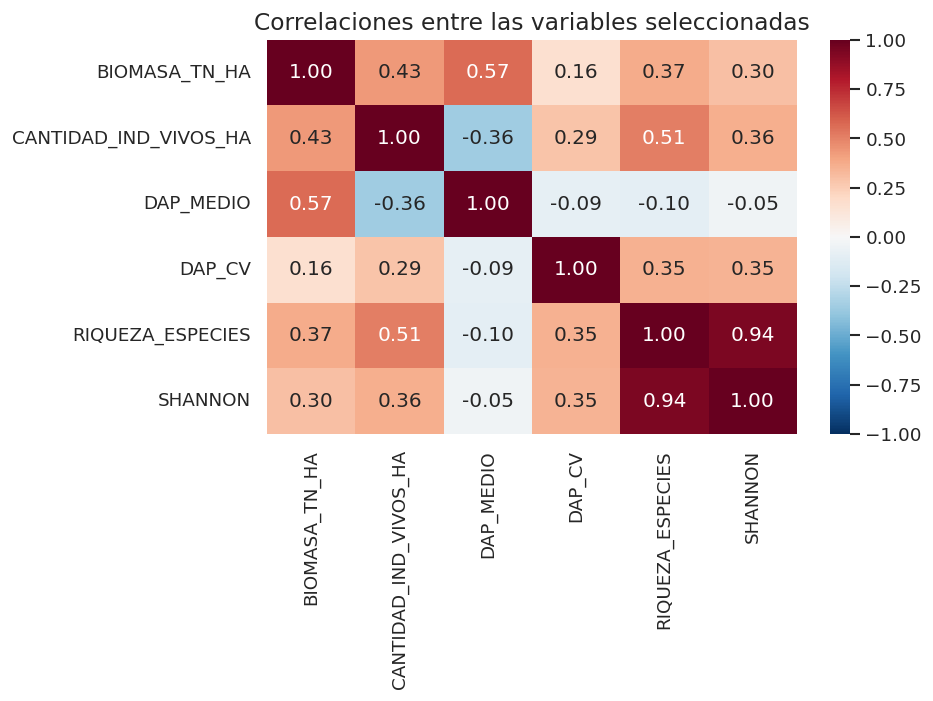

In [5]:
corr = df_cluster[variables_cluster].corr(method='spearman')
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlaciones entre las variables seleccionadas')
plt.tight_layout()
plt.show()

La biomasa mantiene una relación esperable con el porte y, en menor medida, con la densidad. Riqueza y Shannon también están relacionados, pero no son equivalentes: dos parcelas pueden tener la misma cantidad de especies y distribuciones de abundancia muy distintas. Se mantienen ambas porque representan aspectos complementarios de la composición.

## 3.5. Preparación de la matriz

K-means utiliza distancias. Por eso, las escalas originales no pueden compararse directamente. La preparación se realiza en tres pasos:

1. Se acotan los valores al percentil 1-99 dentro de la copia de modelado. Esto reduce la influencia de las colas extremas sin eliminar parcelas ni modificar la base curada.
2. Se aplica `log1p` a biomasa, densidad y DAP medio, que presentan asimetría positiva.
3. Se utiliza `RobustScaler`, menos sensible a valores extremos que el escalado basado en media y desvío.

In [6]:
X_cluster = df_cluster[variables_cluster].copy()
limites_modelo = {}

for variable in variables_cluster:
    p01, p99 = X_cluster[variable].quantile([0.01, 0.99])
    limites_modelo[variable] = (p01, p99)
    X_cluster[variable] = X_cluster[variable].clip(p01, p99)

variables_log = ['BIOMASA_TN_HA', 'CANTIDAD_IND_VIVOS_HA', 'DAP_MEDIO']
X_cluster[variables_log] = np.log1p(X_cluster[variables_log].clip(lower=0))

escalador = RobustScaler()
X_escalado = escalador.fit_transform(X_cluster)
X_escalado = pd.DataFrame(
    X_escalado, columns=variables_cluster, index=df_cluster.index
)

display(X_escalado.describe().round(2))

,BIOMASA_TN_HA,CANTIDAD_IND_VIVOS_HA,DAP_MEDIO,DAP_CV,RIQUEZA_ESPECIES,SHANNON
count,3790.00,3790.00,3790.00,3790.00,3790.0,3790.00
mean,-0.06,-0.09,0.12,0.16,0.0,-0.08
std,0.80,0.75,0.90,1.04,0.7,0.73
min,-2.11,-2.29,-2.52,-1.73,-1.0,-1.55
25%,-0.54,-0.55,-0.43,-0.46,-0.6,-0.53
50%,0.00,0.00,0.00,0.00,0.0,0.00
75%,0.46,0.45,0.57,0.54,0.4,0.47
max,1.72,1.31,2.85,4.97,2.0,1.34


## 3.6. ¿Cuántos grupos tienen sentido?

Probamos entre 2 y 8 clusters. No existe una única métrica que determine la cantidad correcta, por lo que combinamos:

- **Silhouette:** cuanto más alto, mayor separación y cohesión.
- **Davies-Bouldin:** cuanto más bajo, mejor diferenciados están los grupos.
- **Calinski-Harabasz:** cuanto más alto, mayor separación relativa.
- Tamaño de los grupos y posibilidad de interpretarlos forestalmente.

In [7]:
evaluacion_k = []
modelos_k = {}

for k in range(2, 9):
    modelo = KMeans(n_clusters=k, n_init=50, random_state=SEED)
    etiquetas = modelo.fit_predict(X_escalado)
    modelos_k[k] = modelo
    evaluacion_k.append({
        'k': k,
        'silhouette': silhouette_score(X_escalado, etiquetas),
        'davies_bouldin': davies_bouldin_score(X_escalado, etiquetas),
        'calinski_harabasz': calinski_harabasz_score(X_escalado, etiquetas),
        'cluster_mas_chico': pd.Series(etiquetas).value_counts().min(),
    })

evaluacion_k = pd.DataFrame(evaluacion_k)
display(evaluacion_k.round(3))

,k,silhouette,davies_bouldin,calinski_harabasz,cluster_mas_chico
0,2,0.244,1.538,1257.710,1841
1,3,0.248,1.332,1166.364,732
2,4,0.271,1.184,1232.186,154
3,5,0.214,1.266,1170.953,152
4,6,0.213,1.254,1105.628,143
5,7,0.215,1.266,1050.048,141
6,8,0.216,1.221,1005.107,65


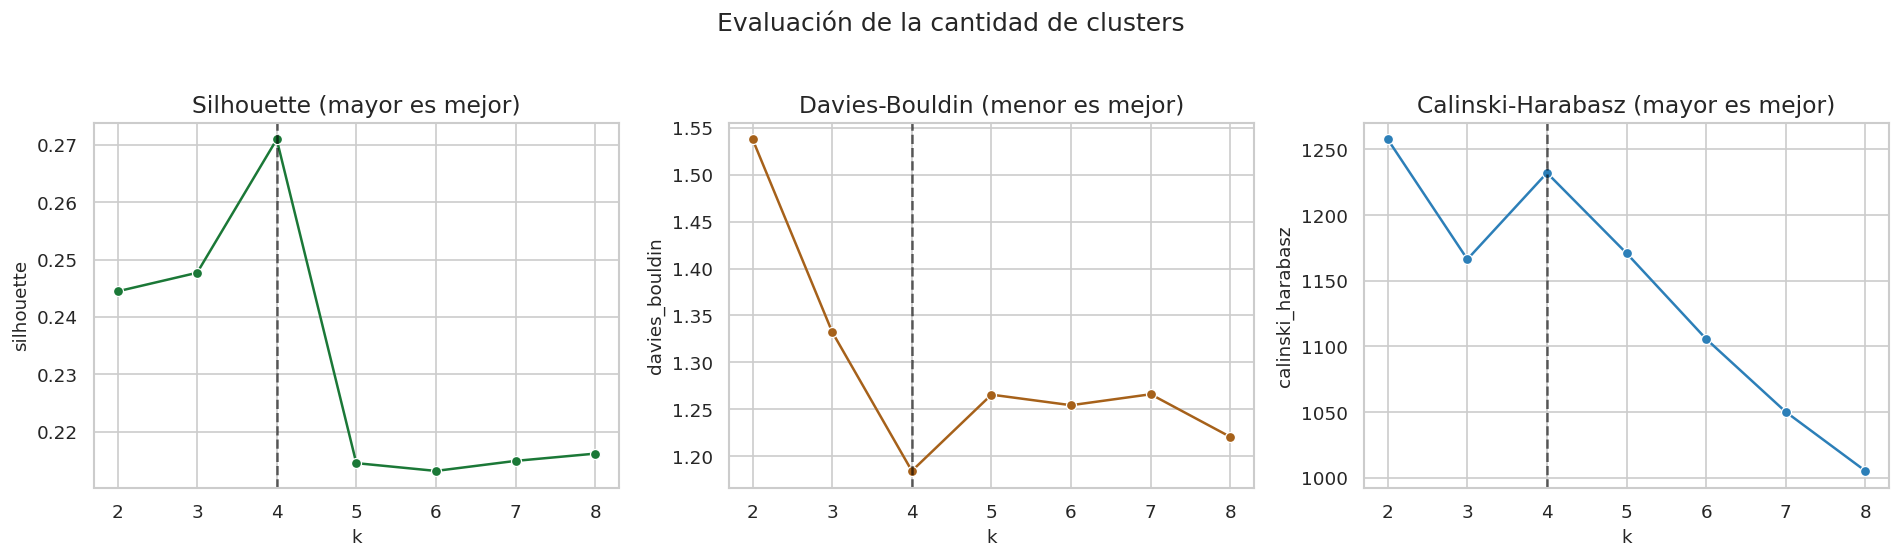

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.lineplot(data=evaluacion_k, x='k', y='silhouette', marker='o', ax=axes[0], color='#1b7837')
axes[0].set_title('Silhouette (mayor es mejor)')

sns.lineplot(data=evaluacion_k, x='k', y='davies_bouldin', marker='o', ax=axes[1], color='#a6611a')
axes[1].set_title('Davies-Bouldin (menor es mejor)')

sns.lineplot(data=evaluacion_k, x='k', y='calinski_harabasz', marker='o', ax=axes[2], color='#2c7fb8')
axes[2].set_title('Calinski-Harabasz (mayor es mejor)')

for ax in axes:
    ax.axvline(4, color='black', linestyle='--', alpha=0.6)
    ax.set_xticks(range(2, 9))

plt.suptitle('Evaluación de la cantidad de clusters', y=1.03, fontsize=15)
plt.tight_layout()
plt.show()

La mejor solución relativa aparece con **cuatro grupos**: alcanza el silhouette más alto y el Davies-Bouldin más bajo entre las alternativas evaluadas, sin fragmentar excesivamente la muestra. El silhouette es moderado, por lo que no interpretamos los clusters como categorías naturales rígidas. Son perfiles exploratorios útiles para resumir un continuo forestal complejo.

## 3.7. Modelo final y estabilidad

In [9]:
K_FINAL = 4
modelo_kmeans = modelos_k[K_FINAL]
df_cluster['CLUSTER_NUM'] = modelo_kmeans.labels_

nombres_cluster = {
    0: 'Gran porte y biomasa alta',
    1: 'Bajo porte y menor biomasa',
    2: 'Estructura muy heterogénea',
    3: 'Alta densidad y diversidad',
}
df_cluster['TIPO_BOSQUE'] = df_cluster['CLUSTER_NUM'].map(nombres_cluster)

tamanos = df_cluster['TIPO_BOSQUE'].value_counts().rename('UM').to_frame()
tamanos['porcentaje'] = (tamanos['UM'] / len(df_cluster) * 100).round(1)
display(tamanos)

,UM,porcentaje
TIPO_BOSQUE,,
Alta densidad y diversidad,1665,43.9
Bajo porte y menor biomasa,1304,34.4
Gran porte y biomasa alta,667,17.6
Estructura muy heterogénea,154,4.1


In [10]:
# Estabilidad frente a distintas inicializaciones de K-means
estabilidad = []
for semilla in [1, 7, 21, 42, 99]:
    etiquetas_alt = KMeans(
        n_clusters=K_FINAL, n_init=30, random_state=semilla
    ).fit_predict(X_escalado)
    estabilidad.append({
        'semilla': semilla,
        'ARI respecto del modelo final': adjusted_rand_score(
            modelo_kmeans.labels_, etiquetas_alt
        )
    })

# Comparación con un método jerárquico que usa un criterio diferente
etiquetas_jerarquico = AgglomerativeClustering(
    n_clusters=K_FINAL, linkage='ward'
).fit_predict(X_escalado)

display(pd.DataFrame(estabilidad).round(3))
print('ARI entre K-means y clustering jerárquico:',
      round(adjusted_rand_score(modelo_kmeans.labels_, etiquetas_jerarquico), 3))

ARI entre K-means y clustering jerárquico: 0.392


,semilla,ARI respecto del modelo final
0,1,1.000
1,7,1.000
2,21,0.996
3,42,0.996
4,99,0.999


K-means resulta muy estable frente a diferentes semillas, lo que indica que la solución no depende de una inicialización particular. El acuerdo con el método jerárquico es moderado: ambos reconocen parte de la misma estructura, aunque asignan de manera distinta las parcelas ubicadas en zonas de transición. Esto es coherente con un fenómeno ecológico continuo y refuerza la necesidad de no tratar las etiquetas como límites absolutos.

## 3.8. Visualización de las tipologías

La reducción a dos componentes principales sirve para representar el resultado, pero no reemplaza a las seis variables utilizadas por el algoritmo.

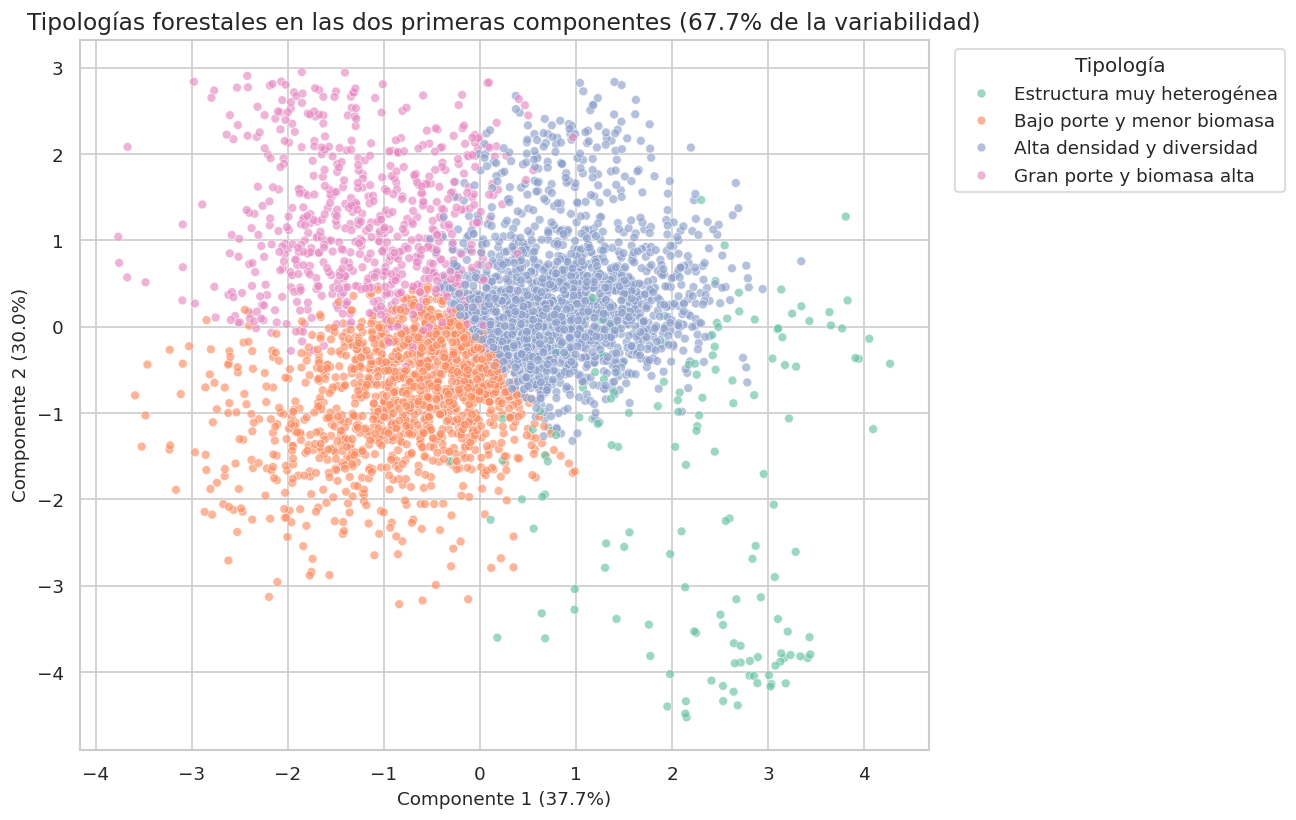

In [11]:
pca = PCA(n_components=2, random_state=SEED)
componentes = pca.fit_transform(X_escalado)
df_cluster['PCA1'] = componentes[:, 0]
df_cluster['PCA2'] = componentes[:, 1]

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_cluster, x='PCA1', y='PCA2', hue='TIPO_BOSQUE',
    palette='Set2', s=28, alpha=0.65
)
plt.title(
    'Tipologías forestales en las dos primeras componentes '\
    f'({pca.explained_variance_ratio_.sum():.1%} de la variabilidad)'
)
plt.xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend(title='Tipología', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3.9. Caracterización de los grupos

Para describir las tipologías volvemos a las variables originales, sin escalado, transformación logarítmica ni acotamiento. De esta manera, las diferencias recuperan su sentido forestal.

In [12]:
variables_perfil = [
    'BIOMASA_TN_HA', 'AREA_BASAL_UM_HA', 'CANTIDAD_IND_VIVOS_HA',
    'MEDIA_ALTURA_UM_EST', 'DAP_MEDIO', 'DAP_CV',
    'RIQUEZA_ESPECIES', 'SHANNON', 'DOMINANCIA',
    'REGENERACION_HA', 'PRESION_ANTROPICA', 'ALTITUD'
]

perfil_mediano = (
    df_cluster.groupby('TIPO_BOSQUE')[variables_perfil]
    .median().round(2)
)
display(perfil_mediano)

,BIOMASA_TN_HA,AREA_BASAL_UM_HA,CANTIDAD_IND_VIVOS_HA,MEDIA_ALTURA_UM_EST,DAP_MEDIO,DAP_CV,RIQUEZA_ESPECIES,SHANNON,DOMINANCIA,REGENERACION_HA,PRESION_ANTROPICA,ALTITUD
TIPO_BOSQUE,,,,,,,,,,,,
Alta densidad y diversidad,56.82,11.54,576.50,6.68,16.77,0.56,9.0,1.80,0.33,3400.0,0.5,180.0
Bajo porte y menor biomasa,15.58,4.34,257.20,5.40,15.49,0.43,4.0,1.06,0.55,2800.0,0.5,228.0
Estructura muy heterogénea,22.35,8.21,431.15,4.69,13.52,1.25,5.0,1.25,0.49,2300.0,0.5,391.0
Gran porte y biomasa alta,86.46,16.28,249.30,9.74,28.65,0.41,3.0,0.65,0.76,1400.0,0.5,463.0


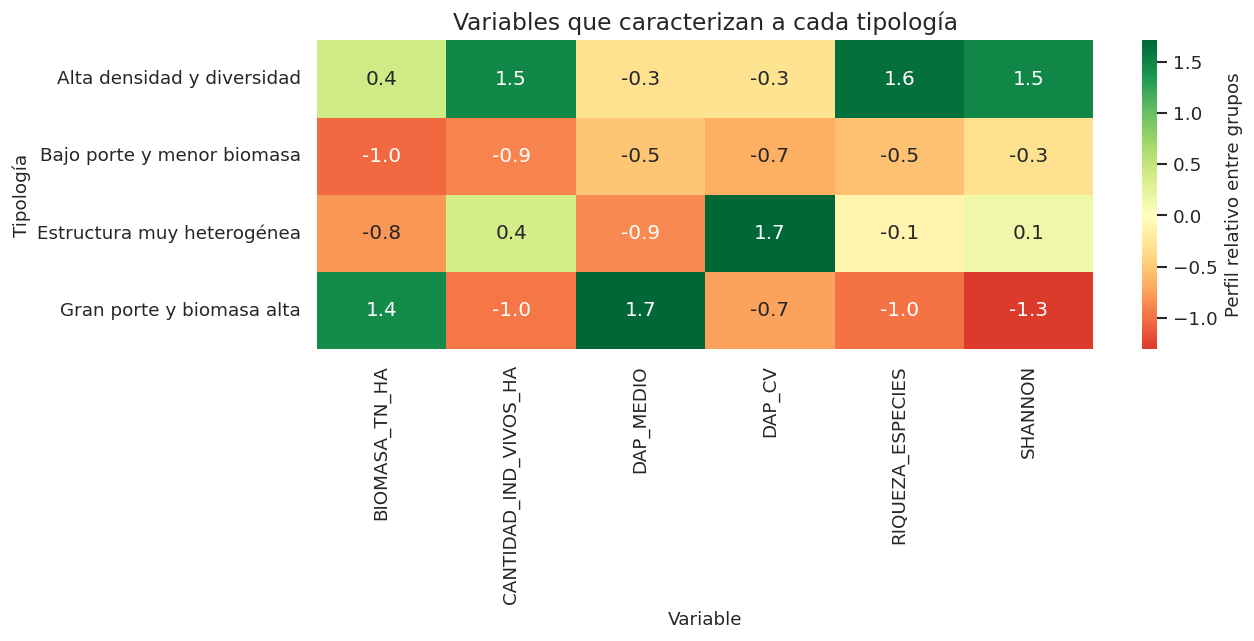

In [13]:
# Perfil relativo: mediana de cada grupo expresada como z-score entre grupos
perfil_relativo = perfil_mediano[variables_cluster].copy()
perfil_relativo = (
    perfil_relativo - perfil_relativo.mean(axis=0)
) / perfil_relativo.std(axis=0, ddof=0)

plt.figure(figsize=(11, 5.5))
sns.heatmap(
    perfil_relativo, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
    cbar_kws={'label': 'Perfil relativo entre grupos'}
)
plt.title('Variables que caracterizan a cada tipología')
plt.xlabel('Variable')
plt.ylabel('Tipología')
plt.tight_layout()
plt.show()

Los cuatro perfiles pueden resumirse de la siguiente manera:

- **Gran porte y biomasa alta:** reúne parcelas con los mayores diámetros, alturas, área basal y biomasa. Presenta menor riqueza y mayor dominancia de una especie, un patrón compatible con varios bosques patagónicos y subtropicales de árboles grandes.
- **Bajo porte y menor biomasa:** concentra parcelas con valores bajos de biomasa, área basal y altura. Es el grupo más extendido dentro del Parque Chaqueño, aunque también aparece en otras regiones.
- **Estructura muy heterogénea:** es el grupo más pequeño y se diferencia por una variabilidad diamétrica muy alta, porte medio bajo y biomasa moderada. Se concentra principalmente entre el Monte y el Parque Chaqueño.
- **Alta densidad y diversidad:** presenta la mayor cantidad de individuos, riqueza y diversidad, junto con biomasa intermedia-alta. Predomina en el Parque Chaqueño y reúne buena parte de las parcelas de la Selva Misionera.

Los nombres son descriptivos y no constituyen una clasificación oficial de tipos de bosque.

## 3.10. Relación con las regiones forestales

La región no participó en la formación de los grupos. Por eso, el cruce permite evaluar si las tipologías simplemente reproducen las divisiones territoriales o si aparecen dentro de varias regiones.

TIPO_BOSQUE,Alta densidad y diversidad,Bajo porte y menor biomasa,Estructura muy heterogénea,Gran porte y biomasa alta
REGION_OFC,,,,
BAP,0.0,10.9,0.0,89.1
DEL,27.8,50.0,0.0,22.2
ESP,19.4,53.8,3.2,23.7
MON,0.0,22.8,77.2,0.0
PCH,51.2,38.8,2.7,7.4
SMI,72.6,11.6,0.6,15.2
STB,30.1,10.4,0.3,59.2


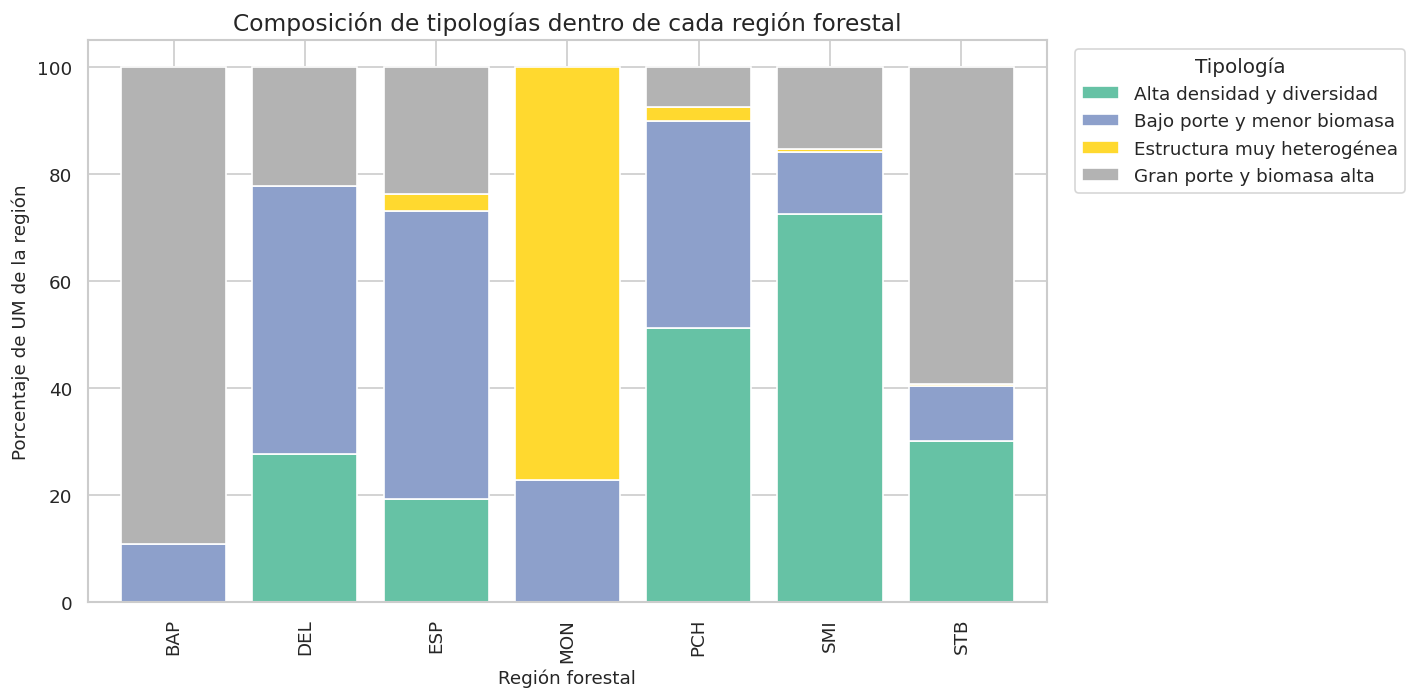

In [14]:
cruce_region = pd.crosstab(
    df_cluster['REGION_OFC'], df_cluster['TIPO_BOSQUE'], normalize='index'
) * 100

display(cruce_region.round(1))

cruce_region.plot(
    kind='bar', stacked=True, figsize=(12, 6), colormap='Set2', width=0.8
)
plt.title('Composición de tipologías dentro de cada región forestal')
plt.xlabel('Región forestal')
plt.ylabel('Porcentaje de UM de la región')
plt.legend(title='Tipología', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Los grupos no son una copia de las regiones. El Bosque Andino Patagónico se concentra fuertemente en el perfil de gran porte y biomasa alta, y el Monte en el perfil de estructura muy heterogénea. En cambio, el Parque Chaqueño se divide entre distintas tipologías, especialmente la de bajo porte y la de alta densidad y diversidad. Esto muestra que una misma región contiene estructuras forestales diferentes y que algunos perfiles atraviesan más de una región.

## 3.11. Distribución espacial de los grupos

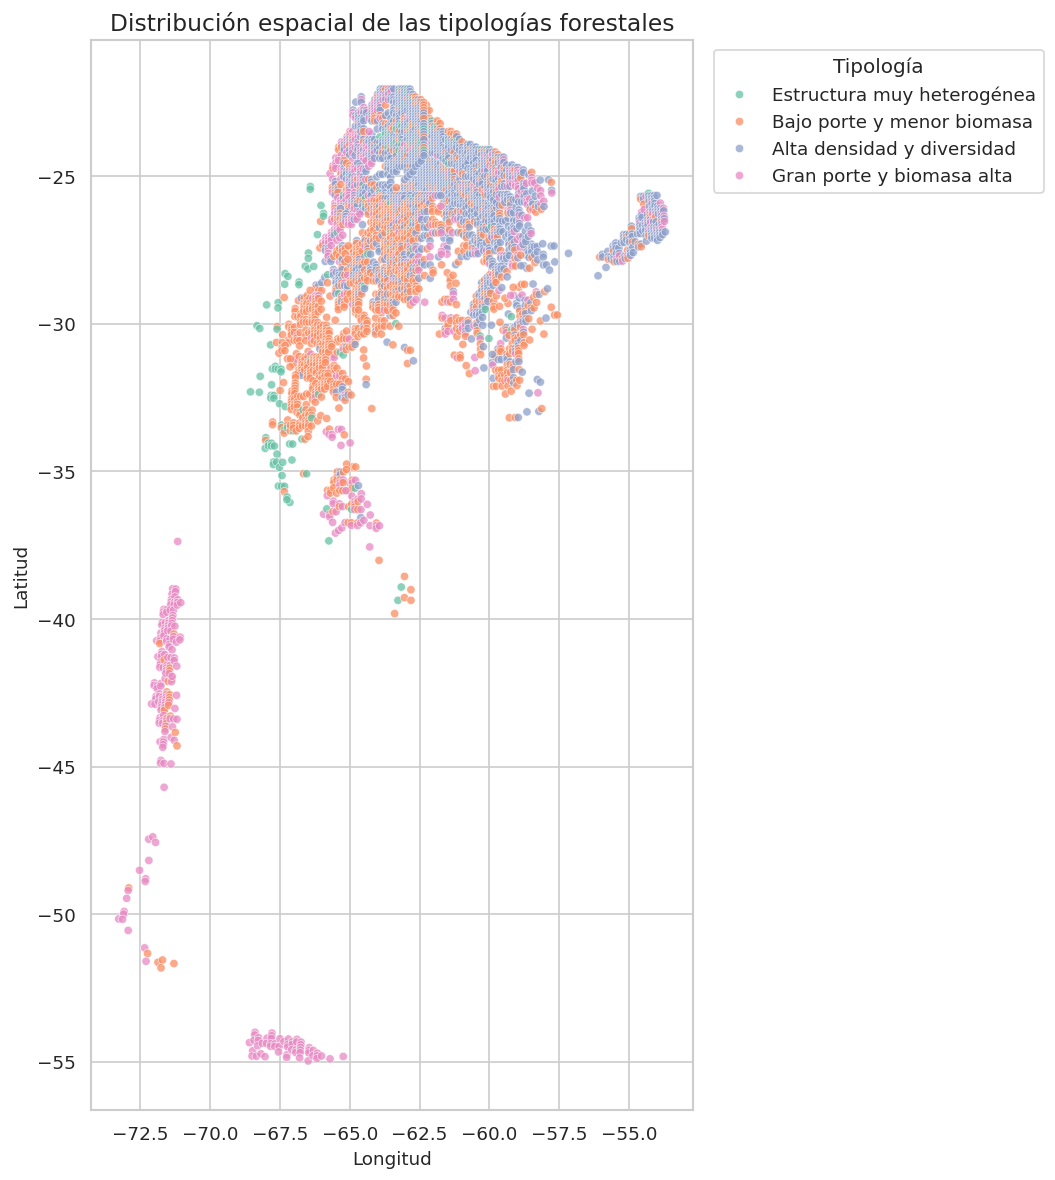

In [15]:
plt.figure(figsize=(9, 10))
sns.scatterplot(
    data=df_cluster, x='LONGITUD', y='LATITUD', hue='TIPO_BOSQUE',
    palette='Set2', s=25, alpha=0.75
)
plt.title('Distribución espacial de las tipologías forestales')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Tipología', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

La distribución espacial confirma que existen concentraciones territoriales claras, pero también zonas de superposición. Las tipologías permiten resumir diferencias estructurales que no quedan contenidas completamente en una regionalización administrativa o ecológica previa.

## 3.12. Variables externas: regeneración y presión antrópica

Estas variables no se usaron para formar los clusters. Se incorporan después para observar si los perfiles estructurales también presentan diferencias en procesos de regeneración o señales de intervención humana. Las asociaciones encontradas son descriptivas y no deben interpretarse como relaciones causales.

In [16]:
resumen_externo = df_cluster.groupby('TIPO_BOSQUE').agg(
    UM=('UM_ID_UM', 'size'),
    regeneracion_mediana=('REGENERACION_HA', 'median'),
    porcentaje_con_regeneracion=('TIENE_REGENERACION', lambda s: s.mean() * 100),
    presion_media=('PRESION_ANTROPICA', 'mean'),
    altitud_mediana=('ALTITUD', 'median'),
    porcentaje_protocolo_completo=('PROTOCOLO_COMPLETO', lambda s: s.mean() * 100),
).round(2)

display(resumen_externo)

,UM,regeneracion_mediana,porcentaje_con_regeneracion,presion_media,altitud_mediana,porcentaje_protocolo_completo
TIPO_BOSQUE,,,,,,
Alta densidad y diversidad,1665,3400.0,98.02,0.38,180.0,70.45
Bajo porte y menor biomasa,1304,2800.0,95.48,0.47,228.0,65.80
Estructura muy heterogénea,154,2300.0,98.05,0.52,391.0,92.21
Gran porte y biomasa alta,667,1400.0,77.66,0.39,463.0,89.51


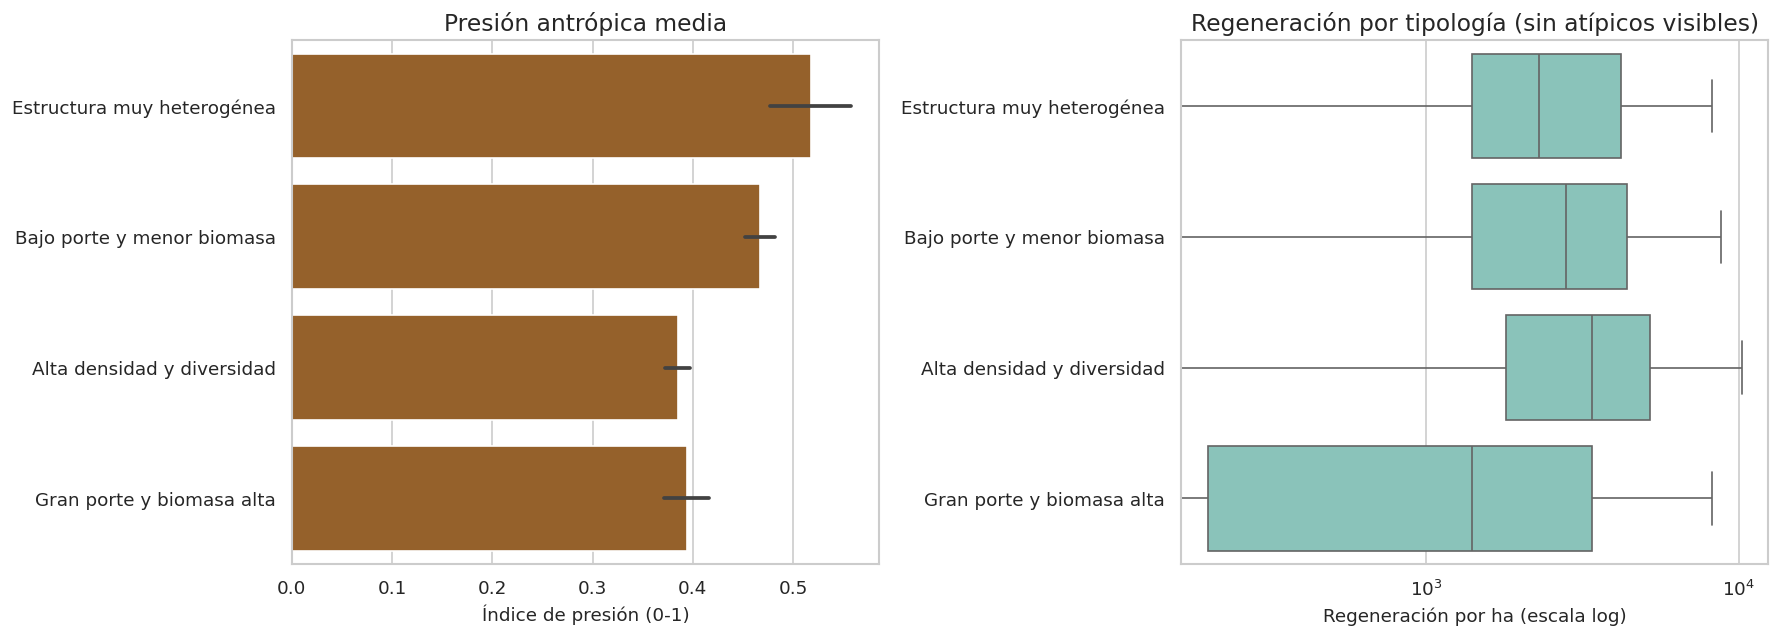

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.barplot(
    data=df_cluster, y='TIPO_BOSQUE', x='PRESION_ANTROPICA',
    estimator='mean', errorbar=('ci', 95), color='#a6611a', ax=axes[0]
)
axes[0].set_title('Presión antrópica media')
axes[0].set_xlabel('Índice de presión (0-1)')
axes[0].set_ylabel('')

sns.boxplot(
    data=df_cluster, y='TIPO_BOSQUE', x='REGENERACION_HA',
    showfliers=False, color='#80cdc1', ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_title('Regeneración por tipología (sin atípicos visibles)')
axes[1].set_xlabel('Regeneración por ha (escala log)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

El grupo de estructura muy heterogénea presenta, en promedio, la mayor presión antrópica, mientras que los perfiles de gran porte y de alta densidad y diversidad muestran valores menores. La regeneración también cambia entre grupos, aunque su dispersión interna es elevada. Estas diferencias abren preguntas específicas, pero no permiten afirmar que la presión sea la causa directa de la estructura observada.

# 3.13. Profundización supervisada: estimación de biomasa

Como complemento, evaluamos si la biomasa por hectárea puede estimarse a partir de variables estructurales, de composición y del sitio.

Para evitar una fuga directa de información, no utilizamos como predictores el área basal, el volumen, el carbono, `BIOMASA_POR_AB` ni otras columnas que contienen o replican matemáticamente la biomasa. La variable objetivo se transforma con `log1p` durante el entrenamiento, pero las métricas finales también se calculan en toneladas por hectárea para conservar una interpretación biológica.

In [18]:
predictores = [
    'ALTITUD', 'CANTIDAD_IND_VIVOS_HA', 'MEDIA_ALTURA_UM_EST',
    'DAP_MEDIO', 'DAP_CV', 'RIQUEZA_ESPECIES', 'SHANNON',
    'DOMINANCIA', 'PRESION_ANTROPICA', 'REGENERACION_HA',
    'DENSIDAD_MADERA_PONDERADA', 'PROP_IND_GRANDES'
]
objetivo = 'BIOMASA_TN_HA'

datos_sup = df_modelo.dropna(subset=[objetivo]).copy()
X_sup = datos_sup[predictores]
y_sup_log = np.log1p(datos_sup[objetivo])

modelos = {
    'Ridge': Pipeline([
        ('imputacion', SimpleImputer(strategy='median')),
        ('escalado', RobustScaler()),
        ('modelo', Ridge(alpha=1.0)),
    ]),
    'Random Forest': Pipeline([
        ('imputacion', SimpleImputer(strategy='median')),
        ('modelo', RandomForestRegressor(
            n_estimators=350, min_samples_leaf=3, max_features=0.8,
            n_jobs=-1, random_state=SEED
        )),
    ]),
    'HistGradientBoosting': Pipeline([
        ('imputacion', SimpleImputer(strategy='median')),
        ('modelo', HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
            l2_regularization=1.0, random_state=SEED
        )),
    ]),
}

### Validación cruzada y control de sobreajuste

La validación usa cinco particiones estratificadas por región para que cada fold conserve una composición regional parecida. Se informan el desempeño medio de entrenamiento y de validación sobre la biomasa transformada. Una brecha muy grande entre ambos sería una señal de sobreajuste.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_cv = []

for nombre, modelo in modelos.items():
    train_scores, val_scores = [], []
    for idx_train, idx_val in cv.split(X_sup, datos_sup['REGION_OFC']):
        X_train_cv = X_sup.iloc[idx_train]
        X_val_cv = X_sup.iloc[idx_val]
        y_train_cv = y_sup_log.iloc[idx_train]
        y_val_cv = y_sup_log.iloc[idx_val]

        modelo.fit(X_train_cv, y_train_cv)
        train_scores.append(r2_score(y_train_cv, modelo.predict(X_train_cv)))
        val_scores.append(r2_score(y_val_cv, modelo.predict(X_val_cv)))

    resultados_cv.append({
        'modelo': nombre,
        'R2 train': np.mean(train_scores),
        'R2 validación': np.mean(val_scores),
        'desvío validación': np.std(val_scores),
        'brecha train-validación': np.mean(train_scores) - np.mean(val_scores),
    })

resultados_cv = pd.DataFrame(resultados_cv).sort_values(
    'R2 validación', ascending=False
)
display(resultados_cv.round(3))

,modelo,R2 train,R2 validación,desvío validación,brecha train-validación
2,HistGradientBoosting,0.982,0.955,0.005,0.027
1,Random Forest,0.980,0.934,0.006,0.046
0,Ridge,0.806,0.798,0.021,0.008


Los modelos no lineales superan al modelo lineal. `HistGradientBoosting` logra el mejor equilibrio entre desempeño y brecha de generalización, mientras que Random Forest muestra una diferencia algo mayor entre entrenamiento y validación. Esto indica que las relaciones con la biomasa no son completamente lineales.

### Evaluación final en un conjunto reservado

Reservamos el 20% de las UM y mantenemos la proporción de regiones. Las predicciones se devuelven a la escala original antes de calcular MAE y RMSE.

In [20]:
idx_train, idx_test = train_test_split(
    np.arange(len(datos_sup)), test_size=0.20, random_state=SEED,
    stratify=datos_sup['REGION_OFC']
)

X_train = X_sup.iloc[idx_train]
X_test = X_sup.iloc[idx_test]
y_train_log = y_sup_log.iloc[idx_train]
y_test_original = datos_sup[objetivo].iloc[idx_test]

resultados_test = []
predicciones = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train_log)
    pred_log = modelo.predict(X_test)
    pred_original = np.expm1(pred_log).clip(min=0)
    predicciones[nombre] = pred_original

    resultados_test.append({
        'modelo': nombre,
        'R2 escala log': r2_score(np.log1p(y_test_original), pred_log),
        'R2 escala original': r2_score(y_test_original, pred_original),
        'MAE (Tn/ha)': mean_absolute_error(y_test_original, pred_original),
        'RMSE (Tn/ha)': mean_squared_error(y_test_original, pred_original) ** 0.5,
    })

resultados_test = pd.DataFrame(resultados_test).sort_values('MAE (Tn/ha)')
display(resultados_test.round(3))

,modelo,R2 escala log,R2 escala original,MAE (Tn/ha),RMSE (Tn/ha)
2,HistGradientBoosting,0.963,0.875,10.318,29.316
1,Random Forest,0.940,0.795,13.050,37.523
0,Ridge,0.798,-6.467,31.499,226.402


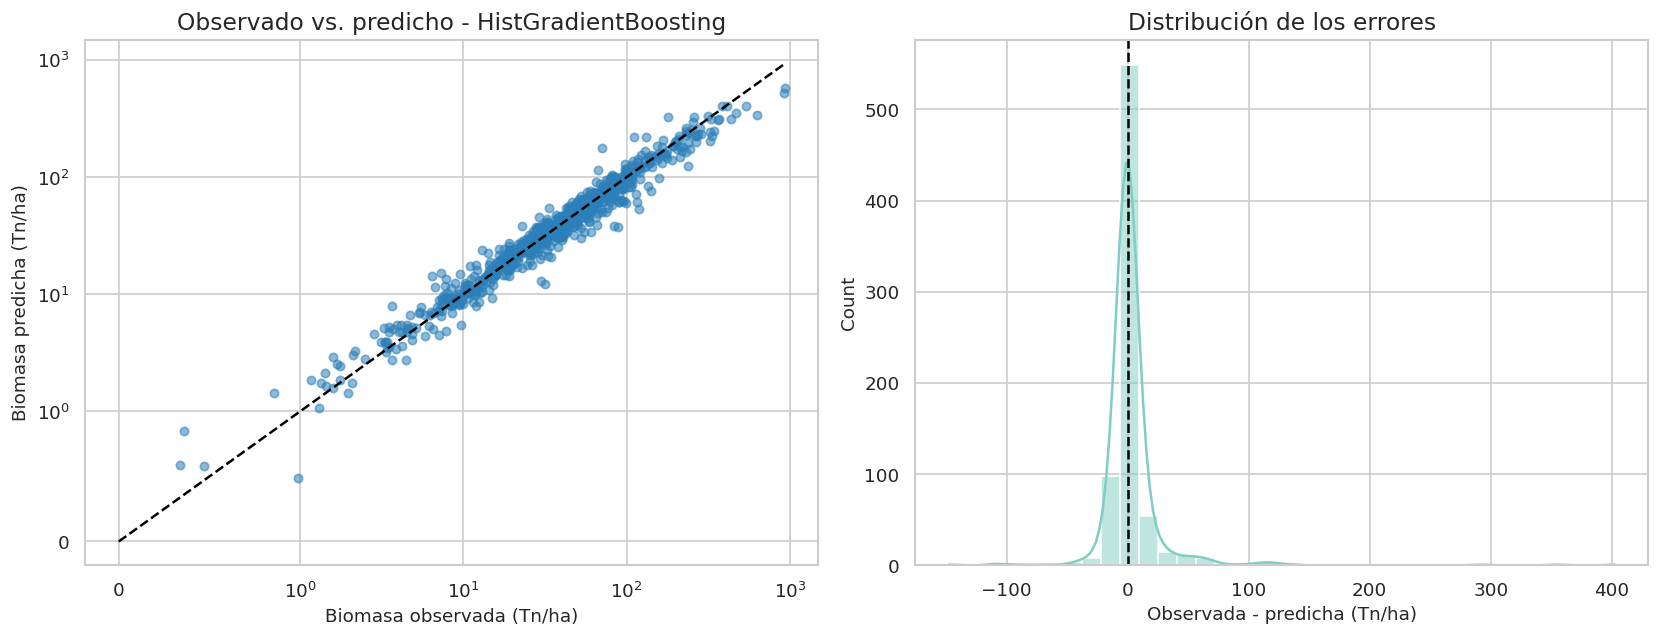

In [21]:
mejor_nombre = resultados_test.iloc[0]['modelo']
mejor_modelo = modelos[mejor_nombre]
mejor_pred = predicciones[mejor_nombre]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(y_test_original, mejor_pred, alpha=0.55, s=25, color='#2c7fb8')
limite = max(y_test_original.max(), mejor_pred.max())
axes[0].plot([0, limite], [0, limite], '--', color='black')
axes[0].set_xscale('symlog', linthresh=1)
axes[0].set_yscale('symlog', linthresh=1)
axes[0].set_title(f'Observado vs. predicho - {mejor_nombre}')
axes[0].set_xlabel('Biomasa observada (Tn/ha)')
axes[0].set_ylabel('Biomasa predicha (Tn/ha)')

residuos = y_test_original.to_numpy() - mejor_pred
sns.histplot(residuos, bins=35, kde=True, color='#80cdc1', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribución de los errores')
axes[1].set_xlabel('Observada - predicha (Tn/ha)')

plt.tight_layout()
plt.show()

### ¿Qué variables aportan más?

La importancia por permutación mide cuánto empeora el modelo cuando se desordena cada predictor en el conjunto de prueba. No implica causalidad, pero ayuda a identificar qué información utiliza con mayor intensidad.

,variable,importancia,desvio
1,CANTIDAD_IND_VIVOS_HA,0.690,0.021
3,DAP_MEDIO,0.494,0.011
2,MEDIA_ALTURA_UM_EST,0.284,0.009
10,DENSIDAD_MADERA_PONDERADA,0.042,0.003
11,PROP_IND_GRANDES,0.040,0.003
4,DAP_CV,0.014,0.001
0,ALTITUD,0.007,0.001
6,SHANNON,0.002,0.000
5,RIQUEZA_ESPECIES,0.001,0.000
7,DOMINANCIA,0.001,0.000


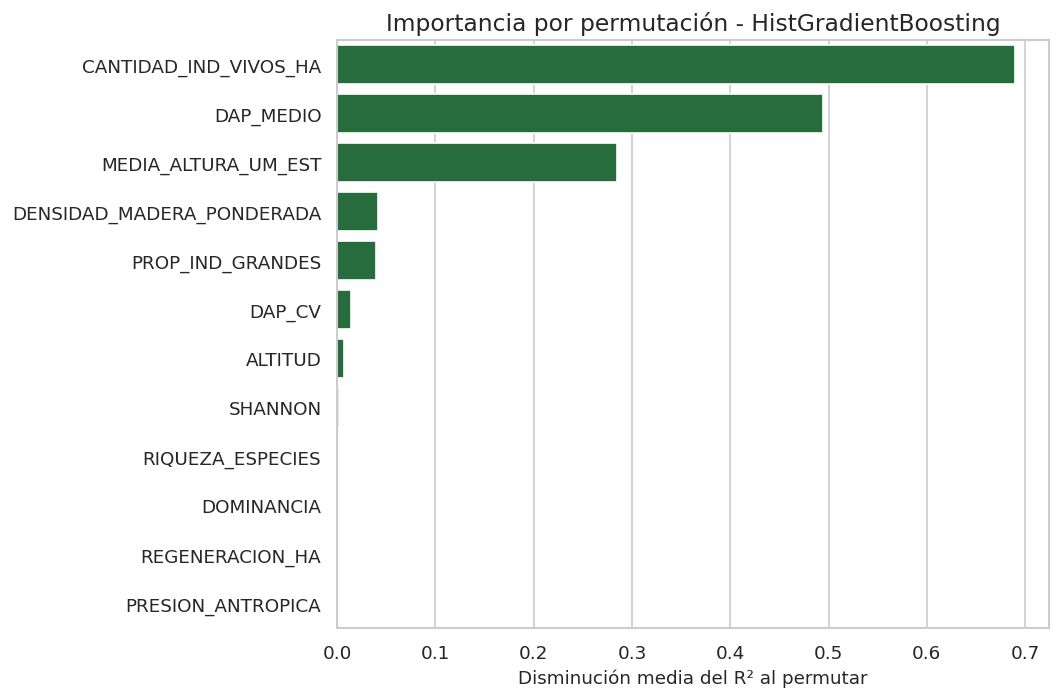

In [22]:
perm = permutation_importance(
    mejor_modelo, X_test, np.log1p(y_test_original),
    scoring='r2', n_repeats=15, random_state=SEED, n_jobs=1
)

importancias = pd.DataFrame({
    'variable': predictores,
    'importancia': perm.importances_mean,
    'desvio': perm.importances_std,
}).sort_values('importancia', ascending=False)

display(importancias.round(3))

plt.figure(figsize=(9, 6))
sns.barplot(data=importancias, y='variable', x='importancia', color='#1b7837')
plt.title(f'Importancia por permutación - {mejor_nombre}')
plt.xlabel('Disminución media del R² al permutar')
plt.ylabel('')
plt.tight_layout()
plt.show()

La densidad de individuos, el DAP medio y la altura media concentran la mayor parte de la capacidad predictiva; en un segundo nivel aparecen la densidad de la madera y la proporción de árboles grandes. El resultado es coherente con la construcción biológica de la biomasa: las parcelas con más individuos y árboles de mayor porte tienden a acumular más materia leñosa.

### Generalización entre regiones

La validación aleatoria responde qué tan bien se predicen nuevas parcelas cuando todas las regiones están representadas durante el entrenamiento. Para plantear una exigencia mayor, usamos una validación agrupada que deja una región completa afuera en cada iteración. Así evaluamos si el modelo puede trasladarse a una región que no vio.

In [23]:
modelo_espacial = modelos['HistGradientBoosting']
cv_region = GroupKFold(n_splits=datos_sup['REGION_OFC'].nunique())
resultados_region = []

for idx_train, idx_val in cv_region.split(
    X_sup, y_sup_log, groups=datos_sup['REGION_OFC']
):
    region_val = datos_sup['REGION_OFC'].iloc[idx_val].iloc[0]
    modelo_espacial.fit(X_sup.iloc[idx_train], y_sup_log.iloc[idx_train])
    pred_val = modelo_espacial.predict(X_sup.iloc[idx_val])
    resultados_region.append({
        'región excluida': region_val,
        'n': len(idx_val),
        'R2 log': r2_score(y_sup_log.iloc[idx_val], pred_val),
    })

resultados_region = pd.DataFrame(resultados_region).sort_values('R2 log')
display(resultados_region.round(3))
print('R² medio dejando una región afuera:', round(resultados_region['R2 log'].mean(), 3))

R² medio dejando una región afuera: 0.827


,región excluida,n,R2 log
5,MON,99,0.548
3,BAP,230,0.704
6,DEL,18,0.835
0,PCH,2754,0.897
2,ESP,253,0.925
1,STB,296,0.936
4,SMI,165,0.943


El desempeño disminuye cuando el modelo debe generalizar a una región completamente ausente del entrenamiento. Esto confirma que el desbalance regional no es solo una cuestión de cantidad: las regiones también contienen estructuras forestales diferentes. Por lo tanto, cualquier uso predictivo fuera de la cobertura observada debe informarse con esta limitación.

## 3.14. Exportación de resultados

Se genera una tabla con las tipologías para las UM efectivamente utilizadas en el clustering y una segunda versión de la base curada con la etiqueta incorporada. Las parcelas excluidas del ajuste se mantienen con tipología faltante para no confundir “sin asignación” con un tipo de bosque.

In [24]:
salida_clusters = df_cluster[[
    'UM_ID_UM', 'CLUSTER_NUM', 'TIPO_BOSQUE', 'PCA1', 'PCA2'
]].copy()

df_tp3 = df.merge(
    salida_clusters[['UM_ID_UM', 'CLUSTER_NUM', 'TIPO_BOSQUE']],
    on='UM_ID_UM', how='left'
)

salida_clusters.to_csv('INBN2_tipologias_bosque.csv', index=False)
df_tp3.to_csv('INBN2_um_curado_con_tipologias.csv', index=False)

print('Archivos generados:')
print('  INBN2_tipologias_bosque.csv ->', salida_clusters.shape)
print('  INBN2_um_curado_con_tipologias.csv ->', df_tp3.shape)

Archivos generados:
  INBN2_tipologias_bosque.csv -> (3790, 5)
  INBN2_um_curado_con_tipologias.csv -> (3891, 108)


## 3.15. Conclusiones

El análisis permitió identificar **cuatro tipologías forestales exploratorias** a partir de la estructura y la composición de las unidades de muestreo. Los grupos se diferenciaron principalmente por el porte de los árboles, la biomasa, la densidad de individuos, la heterogeneidad diamétrica y la diversidad de especies.

Las tipologías no reproducen de manera mecánica las regiones forestales. Algunas muestran una asociación territorial marcada, como el perfil de gran porte en el Bosque Andino Patagónico o el de estructura muy heterogénea en el Monte. Otras atraviesan varias regiones, y el Parque Chaqueño se reparte entre perfiles diferentes. Esto sugiere que la regionalización aporta contexto, pero no alcanza por sí sola para describir toda la variabilidad estructural observada.

También aparecieron diferencias en regeneración y presión antrópica. El perfil de estructura muy heterogénea registró la mayor presión media, mientras que los grupos de gran porte y de alta densidad y diversidad presentaron valores menores. Estas asociaciones sirven para orientar nuevas preguntas, aunque no permiten establecer causalidad.

La profundización supervisada mostró que la biomasa puede estimarse con buen desempeño a partir de variables de estructura y composición, especialmente densidad de individuos, diámetro medio y altura. Sin embargo, la capacidad de generalización disminuyó al dejar regiones completas fuera del entrenamiento. Por eso, el alcance territorial del modelo debe considerarse siempre al interpretar sus resultados.

Finalmente, la separación entre clusters fue moderada y el acuerdo con el método jerárquico no fue total. En consecuencia, estos grupos deben entenderse como una primera tipología cuantitativa a escala nacional, no como límites ecológicos definitivos. El siguiente paso sería contrastarlos con la metodología utilizada para el Bosque Andino Patagónico, revisar su sentido con especialistas forestales y evaluar la incorporación de información climática o edáfica.